# **Diplomado IA: Audio y Video - Parte 1**. <br> Práctico 1: Introducción al Análisis de Audio
---
---

**Profesor:**
- Gabriel Sepúlveda

# **Instrucciones Generales**

El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código.

**Nombre alumno:**

El siguiente práctico cuanta con 3 secciones donde cada una contendrá 1 o más actividades a realizar. Algunas actividades correspondrán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.

**Fecha de entrega:** domingo 2 de agosto de 2026, 23:59 hrs.

#Preamble

In [ ]:
!pip3 install resampy # Paquete necesario para version actual de librosa instalada en Colab

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

import pylab

%matplotlib inline
pylab.rcParams['figure.figsize']=9,6 # default: [6, 4]

#Análisis en frecuencia

## Fast Fourier Transform (FFT)

Comenzaremos por analizar una señal sinusoidal que posee una frecuencia de 5 [Hz], una duración de 1[s] y que ha sido muestreada a una tasa de 512 [Hz]. Para ello graficaremos su evolución temporal, así como también, sus componentes en frecuencia (espectro).

In [ ]:
f = 5.0 # [Hz]
sampling_rate = 512
t = np.linspace( 0, 1, sampling_rate ) # [0, 1] [s]
y = np.sin( 2*np.pi*f*t ) # w = 2*pi*f

ax = plt.axes()
ax.plot( t, y )
plt.title( 'Signal' )
plt.xlabel( 'Time [s]' )
plt.ylabel( 'Amplitude' )

Para poder obtener el espectro de la señal sinusoidal, aplicaremos la FFT mediante la función fft de la biblioteca numpy.

In [ ]:
spectrum = np.fft.fft( y )
print( 'y = sin(t) -> dim: %s' % (str(y.shape)) )
print( 'FFT(y)     -> dim: %s' % (str(spectrum.shape)) )

Debido a que el vector de salida de la FFT está compuesto por el espectro tanto de frecuencias positivas, y luego negativas, no podemos graficar este vector para frecuencias continuamente crecientes. Para obtener un vector de frecuencias que esté en concordancia con la salida de la FFT, utilizaremos la función fftfreq de numpy, tal como vemos a continuación.

In [ ]:
# sample_frequencies = fftfreq( n = window_length, d = sample_spacing )

freq_bins = np.fft.fftfreq( spectrum.size, d = 1/float(sampling_rate) )

In [ ]:
plt.plot(freq_bins, spectrum.real)
plt.xlim( (-10, 10) )
plt.xlabel( 'Frequency' )
plt.ylabel( 'Magnitud' )
plt.title( 'Power spectrum' )

## Serie de Fourier

En esta sección, calcularemos la serie de Fourier trigonométrica para un grupo de señales periódicas, para las cuales hemos calculado sus coeficientes $a_{0}$, $a_{k}$ y $b_{k}$ según las ecuaciones que se ven a continuación:


$\hat{f}(t) = \frac{a_{0}}{2} + \sum_{n=1}^{\infty} \left[ a_{n} \cdot cos(\frac{2 \pi}{T} n t) + b_{n} \cdot sin(\frac{2 \pi}{T} n t) \right]$

$a_{0} = \frac{1}{T} \int_{-\frac{T}{2}}^{\frac{T}{2}} f(t) dt$

$a_{n} = \frac{2}{T} \int_{-\frac{T}{2}}^{\frac{T}{2}} f(t) cos(\frac{2 \pi}{T} n t) dt$

$b_{n} = \frac{2}{T} \int_{-\frac{T}{2}}^{\frac{T}{2}} f(t) sin(\frac{2 \pi}{T} n t) dt$

Comenzaremos por definir la función "generate_animation" que nos permitirá generar una animación con la evolución de la señal que estamos aproximando, en la medidad que vamos agregando componentes armónicos de mayor frecuencia (k cada vez mayor).

In [ ]:
import time
from matplotlib import animation, rc

def generate_animation(x, y_history, freq_bins, history_freq):

  fig, (ax1, ax2) = plt.subplots( 2 )

  # Cerramos el gráfico creado porque luego se creará uno con otra función
  # específica para animar
  plt.close()

  ax1.set_ylim( (-2.5, 2.5) )
  ax2.set_xlim( (-100, 100) )

  graph1, = ax1.plot( x, y_history[0] )
  graph2, = ax2.plot( freq_bins, history_freq[0] )

  def animate(i):
    graph1.set_data( x, y_history[i] )
    graph2.set_data( freq_bins, history_freq[i] )

  anim = animation.FuncAnimation( fig, animate, frames = len(y_history) )

  # Este código es para que funcione en google colab
  rc( 'animation', html = 'jshtml' )

  return anim

### Señal cuadrada

A continuación se presentan los coeficientes de la serie de Fourier trigonométrica para una señal cuadrada impar y centrada en cero.


$a_{0} = 0$

$a_{n} = 0$

$b_{n} = \frac{4}{n \cdot \pi} \cdot \left\{
  \begin{array}{ll}
    0 & if \; n \; even \\
    1 & if \; n \; odd
  \end{array}
\right.$

$f(t) = \frac{4}{\pi} \cdot \sum_{n=1, 3, 5,...}^{\infty} \frac{1}{n} \cdot sin( n \cdot 2 \cdot \pi \cdot f \cdot t)$

In [ ]:
import copy

f = 5.0 # [Hz]
sampling_rate = 512
t = np.linspace( 0, 1, sampling_rate ) # [0, 1] [s]
y = np.zeros( t.shape )

history = list()
history_freq = list()

for i in range( 1, 200, 2 ):
  y += (4/np.pi) * (1/float(i)) * np.sin( i*2*np.pi*f*t )
  history.append( copy.copy( y ) )
  fft = np.fft.fft( y )
  spectrum = np.abs( fft )
  history_freq.append( copy.copy( spectrum.real ) )

freq_bins = np.fft.fftfreq( spectrum.size, d = 1/float(sampling_rate) )

generate_animation(t, history, freq_bins, history_freq)

### Señal triangular

A continuación se presentan los coeficientes de la serie de Fourier trigonométrica para una señal triagular impar y centrada en cero.


$a_{0} = 0$

$a_{n} = 0$

$b_{n} = \frac{8}{\pi^2 \cdot n^2} \cdot \left\{
  \begin{array}{lc}
    (-1)^{(n-1)/2} & if \; n \; odd \\ \\
    0 & if \; n \; even
  \end{array}
\right.$

$f(t) = \frac{8}{\pi^2} \cdot \sum_{n=1, 3, 5,...}^{\infty} \frac{(-1)^{(n-1)/2}}{n^2} \cdot sin ( n \cdot 2 \cdot \pi \cdot f \cdot t)$

In [ ]:
import copy

f = 5.0 # [Hz]
sampling_rate = 512
t = np.linspace( 0, 1, sampling_rate ) # [0, 1] [s]
y = np.zeros( t.shape )

history = list()
history_freq = list()

for i in range( 1, 20, 2 ):
  y += (8/(np.pi**2)) * (((-1)**((i-1)/2))/float(i**2)) * np.sin( i*2*np.pi*f*t )
  history.append( copy.copy( y ) )
  fft = np.fft.fft( y )
  spectrum = np.abs( fft )
  history_freq.append( copy.copy( spectrum.real ) )

freq_bins = np.fft.fftfreq( spectrum.size, d = 1/float(sampling_rate) )

generate_animation(t, history, freq_bins, history_freq)

### Señal diente de sierra (sawthoot)

A continuación se presentan los coeficientes de la serie de Fourier trigonométrica para una señal diente de sierra impar y no centrada en cero.

$a_{0} = 1$

$a_{n} = 0$

$b_{n} = - \frac{1}{n \cdot \pi}$

$f(t) = \frac{1}{2} - \frac{1}{\pi} \cdot \sum_{n=1}^{\infty} \frac{1}{n} \cdot sin ( n \cdot 2 \cdot \pi \cdot f \cdot t)$

In [ ]:
import copy

f = 5.0 # [Hz]
sampling_rate = 512
t = np.linspace( 0, 1, sampling_rate ) # [0, 1] [s]
y = np.zeros( t.shape )

history = list()
history_freq = list()

y += 1/2.0
for i in range( 1, 100 ):
  y += - (1/np.pi) * (1/float(i)) * np.sin( i*2*np.pi*f*t )
  history.append( copy.copy( y ) )
  fft = np.fft.fft( y )
  spectrum = np.abs( fft )
  history_freq.append( copy.copy( spectrum.real ) )

freq_bins = np.fft.fftfreq( spectrum.size, d = 1/float(sampling_rate) )

generate_animation(t, history, freq_bins, history_freq)

## Actividades

###Actividad 1.1

Calcule los coeficientes de la serir de Fourier trigonométrica para una señal cuadrada impar, de valor mínimo 0 y valor máximo 2 (no centrada en cero), tal como la que aparece abajo en la figura. Luego, programe una rutina para generar una animación en la cual se vea su formación en la medida que se van agregando componentes armónicos a la serie.

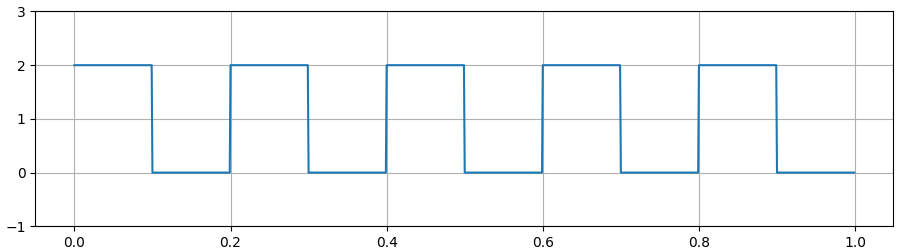

In [ ]:
#Code

###Actividad 1.2

Responda la siguiente pregunta: ¿ En qué se diferencia el **espectro** de la señal cuadrada entregada en el ejemplo (centrada de cero), de la solicitada en la actividad 1.1 ?

**Respuesta:**

#Análisis tiempo-frecuencia

##Short-time fourier transform (STFT)

###STFT sobre un grupo de señales sinusoidales

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pylab

import resampy
import librosa
import librosa.display

%matplotlib inline
pylab.rcParams['figure.figsize'] = 12,6 # default: [6, 4]

In [ ]:
sampling_rate = 8192
t = np.linspace( 0, 8, 8*sampling_rate ) # [0, 8] [s]
dt = int(len(t)/4)

y1 = np.cos( 2*np.pi*10*t[0*dt:1*dt] ) # 10 [Hz]
y2 = np.cos( 2*np.pi*25*t[1*dt:2*dt] ) # 25 [Hz]
y3 = np.cos( 2*np.pi*50*t[2*dt:3*dt] ) # 50 [Hz]
y4 = np.cos( 2*np.pi*100*t[3*dt:4*dt] ) # 100 [Hz]
y = np.concatenate( (y1, y2, y3, y4) )

ax = plt.axes()
scat = ax.plot( t, y )
plt.title( 'Signal' )
plt.xlabel( 'Time [s]' )
plt.ylabel( 'Amplitude' )

In [ ]:
spec = np.abs( librosa.stft( y ) )
print( spec.shape )

fig, ax = plt.subplots()
img = librosa.display.specshow( spec, x_axis = 'time', y_axis = 'linear', sr = sampling_rate, ax = ax ) # librosa default sr 22kHz
ax.set_ylim( [0, 200] )
ax.set( title = 'STFT' )

###STFT sobre un archivo de audio

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

In [ ]:
audio_data, sampling_rate = librosa.load( '100652-3-0-0.wav' )
print('Audio file sampling rate: %d [Hz]' % (sampling_rate))

In [ ]:
ipd.Audio( audio_data, rate = sampling_rate )

In [ ]:
librosa.display.waveshow( audio_data, sr = sampling_rate )

In [ ]:
spec = librosa.stft( audio_data )
spec_db = librosa.amplitude_to_db( np.abs( spec ), ref = np.max ) # 20*log( x / ref )

In [ ]:
fig, ax = plt.subplots()
img = librosa.display.specshow( spec_db, x_axis='time', y_axis='linear', sr = sampling_rate, ax=ax )
ax.set( title = 'Audio signal STFT' )

##Mel Scale based transformations

###Mel-frequency Cepstral Coefficients (MFCC)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pylab

import resampy
import librosa
import librosa.display

%matplotlib inline
pylab.rcParams['figure.figsize'] = 12,6 # default: [6, 4]

In [ ]:
sampling_rate = 8192
t = np.linspace( 0, 8, 8*sampling_rate ) # [0, 8] [s]
dt = int(len(t)/4)

y1 = np.cos( 2*np.pi*10*t[0*dt:1*dt] ) # 10 [Hz]
y2 = np.cos( 2*np.pi*25*t[1*dt:2*dt] ) # 25 [Hz]
y3 = np.cos( 2*np.pi*50*t[2*dt:3*dt] ) # 50 [Hz]
y4 = np.cos( 2*np.pi*100*t[3*dt:4*dt] ) # 100 [Hz]
y = np.concatenate( (y1, y2, y3, y4) )

ax = plt.axes()
scat = ax.plot( t, y )
plt.title( 'Signal' )
plt.xlabel( 'Time [s]' )
plt.ylabel( 'Amplitude' )

In [ ]:
mfccs = librosa.feature.mfcc( y = y, sr = sampling_rate, n_mfcc = 40 )
print(mfccs.shape)

fig, ax = plt.subplots()
img = librosa.display.specshow( mfccs, x_axis = 'time', sr = sampling_rate, fmax = 8000, ax = ax )
fig.colorbar(img, ax=ax)
ax.set(title='MFCC')

###MFCC sobre un archivo de audio

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

In [ ]:
audio_data, sampling_rate = librosa.load( '100652-3-0-0.wav' )
print('Audio file sampling rate: %d [Hz]' % (sampling_rate))

In [ ]:
ipd.Audio( audio_data, rate = sampling_rate )

In [ ]:
librosa.display.waveshow( audio_data, sr = sampling_rate )

In [ ]:
mfccs = librosa.feature.mfcc( y = audio_data, sr = sampling_rate, n_mfcc = 40 )
print( mfccs.shape )

fig, ax = plt.subplots()
img = librosa.display.specshow( mfccs, x_axis = 'time', y_axis = 'mel', sr = sampling_rate, fmax = 8000, ax = ax )
ax.set(title='MFCC')

##Actividades

###Actividad 2.1

Responda la siguiente pregunta: Cuando utilizamos transformaciones basadas en ventanas temporales como en el caso de STFT, ¿ cuál es el efecto sobre la precisión de la frecuencia cuando aumentamos el tamaño de la ventana ?

**Respuesta:**